In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

Before we start, let's load some pandas objects saved as `.csv` files. They are hosted in the course repo, so `pandas` can read them straight from their URLs. No manual upload needed.

In [ ]:
# Load the cleaned dataframe and target prepared using the flights dataset.
# These CSVs are hosted in the course repo, so they load directly in Colab.
base_url = "https://raw.githubusercontent.com/elleobrien/MIDAS_summer_academy_student/main/day02/data/"
y = pd.read_csv(base_url + "y_dep_delay.csv", index_col=0)
cleaned_df = pd.read_csv(base_url + "cleaned_data.csv", index_col=0)

Ok, let's prepare to build a model that predicts **departure delay**!

But before we go into building a model, we first need to split the dataset into two parts :

- data to train the model on
- data to evaluate the model performance.

It is critically important that the two groups of data are strictly separated! But still, we FINALLY get to use the scikit-learn package! Scikit-learn has a function for this!

see https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html for more information

In [ ]:
from sklearn.model_selection import train_test_split
X_train_df, X_test_df, y_train, y_test = train_test_split(cleaned_df, y, test_size=0.25, random_state=42)

https://en.wikipedia.org/wiki/42_(number)#The_Hitchhiker's_Guide_to_the_Galaxy

# Training set pre-processing

## One-hot encoding

Unfortunately, we cannot directly start building a model. The dataset needs to be further 'preprocessed' in order to be able to be 'understood' by the computer and for a model to be trained properly. For example, we have seen in the exercises above that carrier are made of letters and numbers. That is not necessarily understandable to a mathematical model. We somehow need to transform them into numbers / vectors.

What type of feature is the 'carrier' column?

For such type of features, we can use what is called the 'one-hot encoder'. It transforms the raw features into a numerical vector understandable by the model.

A visual explanation of the one-hot encoder is shown below.

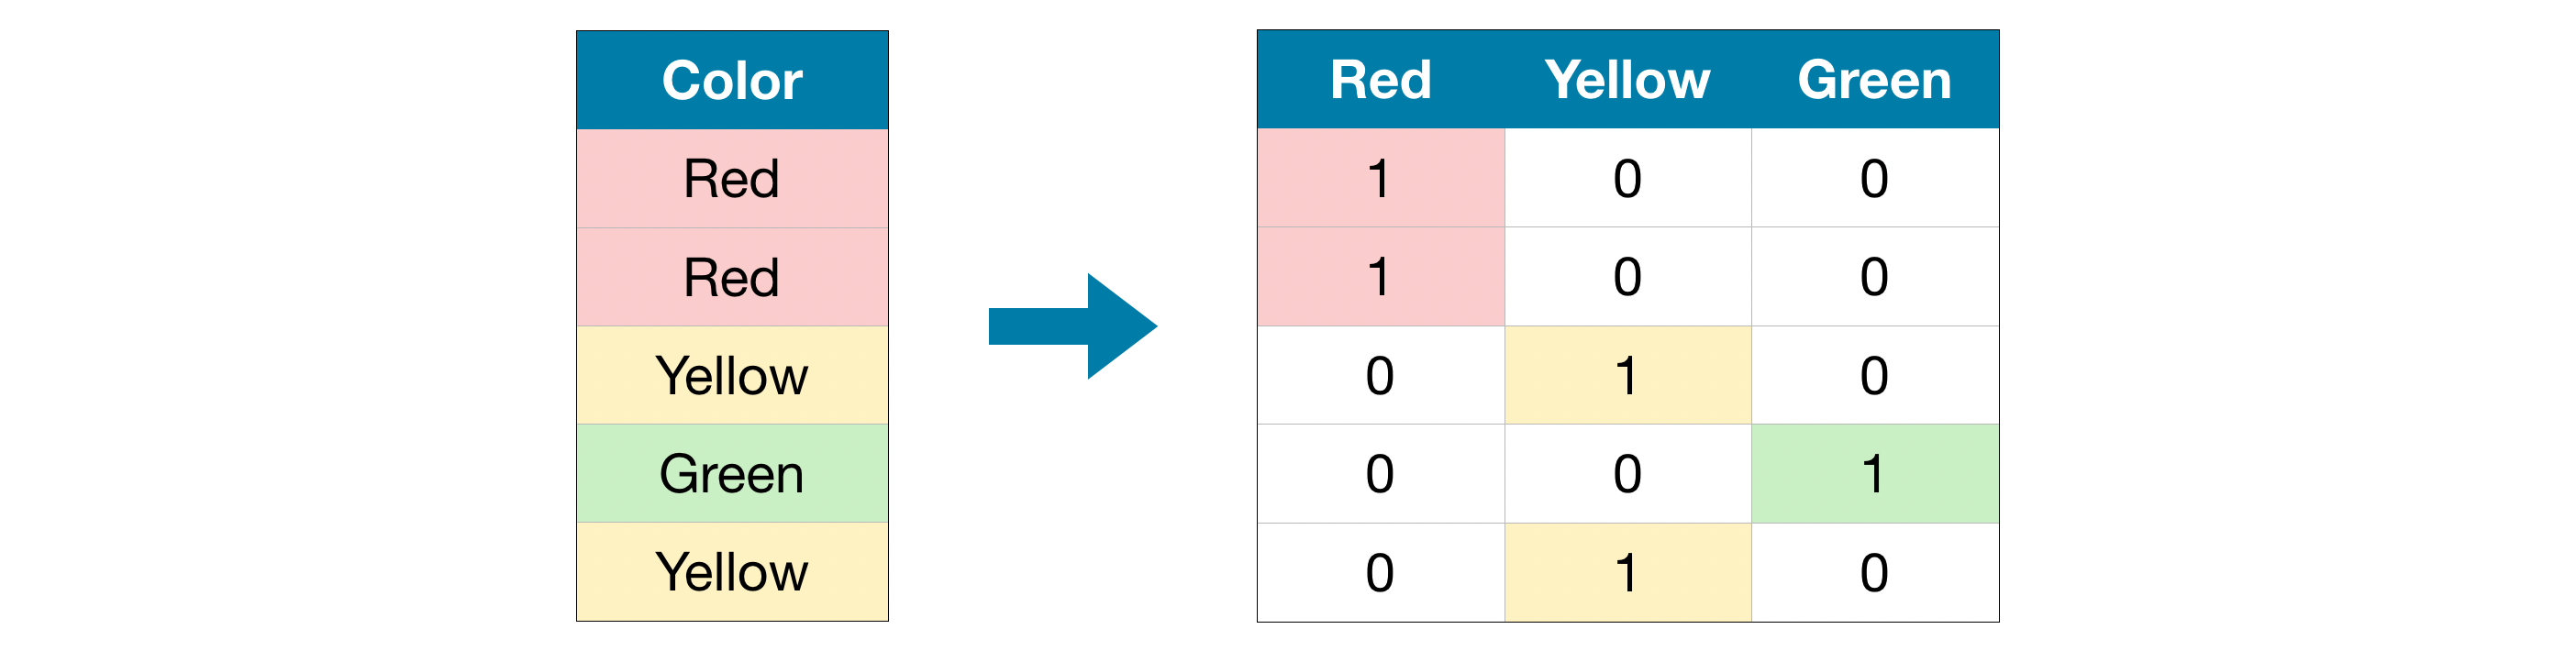

Before moving on, what are two other columns else than the 'carrier' column that would be categorical?

In [ ]:
X_train_df.columns

In [ ]:
from sklearn.preprocessing import OneHotEncoder

see https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

In [ ]:
# The onehot encoder allows to treat multiple categorical feature columns simultaneously.

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False) # First declare a preprocessing object
cat_array_train = ohe.fit_transform(X_train_df.loc[:, ["carrier", "origin", "dest"]]) # fit the preprocessing object and transform the column

In [ ]:
# Let's take a look at what the one-hot encoded array looks like.
cat_array_train.shape

In [ ]:
# Let's take a look at how each category was transformed.
print(ohe.categories_)
print()
num_categories = 0
for array in ohe.categories_ :
    num_categories += len(array)
print("There is a total of ", num_categories, " categories.")

You can see how the number of every unique value in these feature columns are transformed to have a single column in the one-hot encoded array.

In [ ]:
# Let's look at what values are in the one-hot encoded array.
np.unique(cat_array_train)

In [ ]:
# More importantly, let's try to make a connection between the one-hot vector and the actual values.
# First, let's look at the one-hot array for the carrier.
cat_array_train[:5, :16]

In [ ]:
# Now let's look at the actual values of the carrier from the dataframe.
X_train_df.iloc[:5, list(X_train_df.columns).index("carrier")]

We see how we can connect back to the actual values from the onehot encoded array.

## Standardization

We still aren't done here! For the model that we'll first try to use, numerical values should be "normalized". That is, the values need to be re-scaled such that the average is zero and standard deviation equals one through the following equation.

$$
\mathbf{z}=(\mathbf{x}-\mu)/\sigma
$$

In [ ]:
# Q) Using what we learned in numpy or pandas, can you try to normalize the "distance" column in X_train_df?
distance_column = X_train_df["distance"]
dist_mean =
dist_std = distance_column.std(ddof=0) # ddof=0 is used to calculate the population standard deviation
normalized_distance_column =

There actually is a function in scikit learn that does this! It's called StandardScaler.

See https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

distance_scaler = StandardScaler()
distance_array = distance_scaler.fit_transform(X_train_df["distance"].to_frame())

Let's compare the two results.

In [ ]:
np.allclose(normalized_distance_column.to_numpy(), distance_array.flatten(), atol=1e-12)

Did you notice how the process of using StandardScaler is the same as using OneHotEncoder? You can actually transform multiple columns at once as we did with OneHotEncoder.

In [ ]:
# Q) Can you apply StandardScaler to the columns 'distance', 'air_time' and 'arr_delay' ?
std_scaler =
std_array_train =

In [ ]:
std_array_train.shape, X_train_df.loc[:, ["distance", "air_time", "arr_delay"]].shape

## Scaling

Now, let's look at the MinMaxScaler. This scaler transforms the feature values to be between a specified range, of which 0 to 1 being most common. The Month and Day looks like good columns to transform using this, as it relevant to the portion of the year that has passed by. Again, the pattern of using this scaler is the same as what we saw above! Hopefully you start to recognize and appreciate the well-organized structure of the scikit-learn library.

You can take a look at the reference of min max scaler here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Q) Without any help from us, try min max scaling the 'month' and 'day' columns.
minmax_scaler =
minmax_array_train =

In [ ]:
# Q) How do you look at the type of the output?
# YOUR CODE HERE #

In [ ]:
minmax_array_train.shape

In [ ]:
# Q) Can you get the minimum and maximum values across the zero axis?
# Hint: https://numpy.org/doc/2.2/reference/generated/numpy.min.html
print("Minimum values across the zero axis:", #YOUR CODE HERE#)
print("Maximum values across the zero axis:", #YOUR CODE HERE#)

We have the last four columns to take care of. It turns out that the 'hour' and 'minute' columns are simply 'sched_dep_time' split into hours and minutes. Let's take a look at the first few instances.

In [ ]:
print("Sched dep time column values")
print(X_train_df["sched_dep_time"][:5])

However, we do not want to keep columns that perfectly overlap in terms of information. So we'll eventually remove the 'hour' and 'minute' columns. However, in it's raw form, 'sched_dep_time' format doesn't make much sense. Let's try to get it through a MinMaxScaler so that 12:00 AM corresponds to 0 and 11:59 PM corresponds to 1. We can transform the times into number of minutes to do that. While we did cover the three most popular preprocessing and scaling options, take a look at the scikit learn document below for other options and how they compare to one another.

https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-scaler

https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py

In [ ]:
X_train_df["hour"] = X_train_df["sched_dep_time"]//100

In [ ]:
X_train_df["minute"] = X_train_df["sched_dep_time"]%100

In [ ]:
X_train_df["sched_dep_time"].head()

In [ ]:
time_in_min = 60 * X_train_df["hour"] + X_train_df["minute"]
print(max(time_in_min))
sched_dep_time_scaler = MinMaxScaler()
sched_dep_time_array_train = sched_dep_time_scaler.fit_transform(time_in_min.to_frame())

In [ ]:
# Q) Can you try it for the sched_arr_time column? Change 'None' to your code.
# HINT : you first need to split the values here into hour and time
arr_hour =
arr_min =
arr_time_in_min =
print(max(arr_time_in_min))
print(type(arr_time_in_min))

In [ ]:
# Q) Can you apply the min max scaler to the arr_time_in_min after converting it to a dataframe?
# HINT: https://pandas.pydata.org/docs/reference/api/pandas.Series.to_frame.html
sched_arr_time_scaler =
arr_time_in_min_df =
sched_arr_time_array_train =

## Combining all pre-processed arrays

Now we need to bring together all of the transformed arrays that we've prepared. Because the number of observations (rows) are same across the different arrays, we want to HORIZONTALLY stack the arrays into a single train array. Since we are dealing with a numpy array, we use the '.hstack()' function to do it.

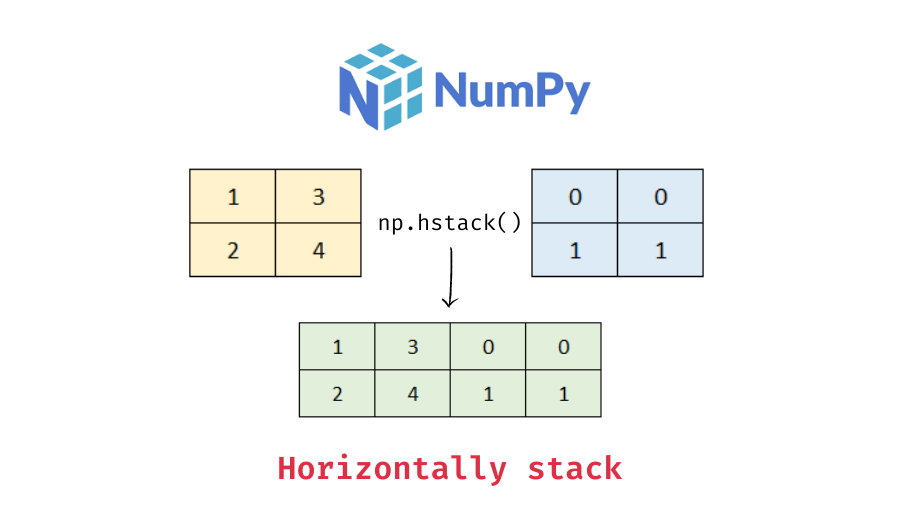
(from datascienceparichay.com)

https://numpy.org/doc/2.1/reference/generated/numpy.hstack.html

Before moving on, though, let's think for one sec - what is the shape that we expect to see?

1.   How many rows did we start off dealing with? Did we remove any?
2.   How many columns should we have?

In [ ]:
X_train = np.hstack([
    cat_array_train,
    std_array_train,
    minmax_array_train,
    sched_dep_time_array_train,
    sched_arr_time_array_train
])

In [ ]:
for array in [
    cat_array_train,
    std_array_train,
    minmax_array_train,
    sched_dep_time_array_train,
    sched_arr_time_array_train
] :
    print(array.shape[1])

In [ ]:
# Q) Let's take a look at how this array actually looks like.
print("Shape of training data:", "# YOUR CODE HERE #", "rows and", "# YOUR CODE HERE #", "features")

Similarly, there is a np.vstack() function, which vertically stacks the arrays given as a list.

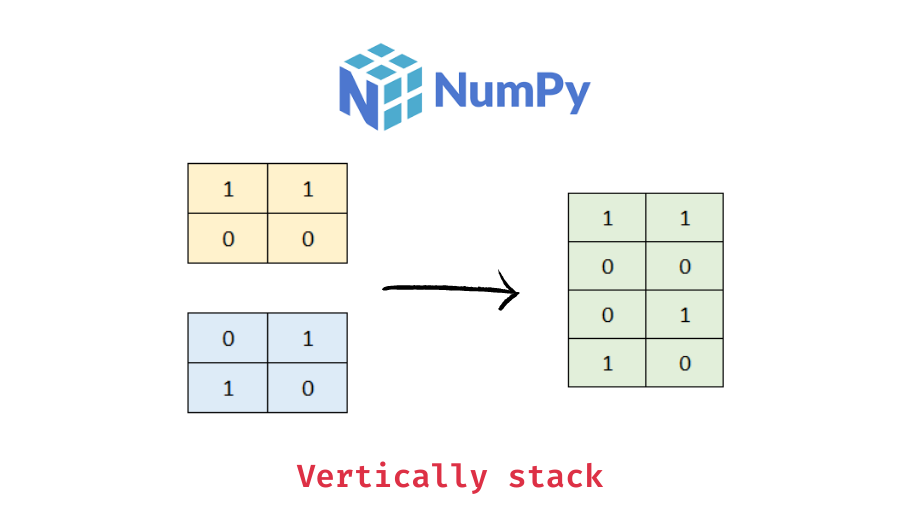 again from datascienceparichay.com

So you've went through one whole loop of pre-processing data.

To briefly summarize what we have done...

1.   we went through all of the individual columns
2.   either transformed or scaled the values appropriately based on the nature of the feature
3.   brought them back together.

One critical aspect that should be mentioned is how the **test set NEVER appeared** during the process. This is because we do not want any information of the test set to slip into the training set. If not, we will be over-estimating its performance. Only after we have a complete preprocessing workflow in hand, we apply the *same* process on the test set.

# Test set preprocessing

In [ ]:
# Now we need to apply all the transformations we've done for the X_test_df...
# We will use the preprocessing objects that has been fitted on the training data!
cat_array_test = ohe.transform(X_test_df.loc[:, ["carrier", "origin", "dest"]])

In [ ]:
# Now that you know that all the preprocessing objects operate the same, can you try out the remaining?

# Q) Apply standardization and min-max scaling to appropriate columns, in the same order as we did for the training data.
std_array_test =
minmax_array_test =

In [ ]:
# Q) Apply the same transformation on departure time as we did for the training data.
test_dep_time_hr =
test_dep_time_min =
test_dep_time_in_min =  # Combine the hour and minute columns into minutes.
test_dep_time_in_min_df =
sched_dep_time_array_test =

In [ ]:
# Q) Repeat on the arrival time.
test_arr_time_in_min =
test_arr_time_in_min_df =
sched_arr_time_array_test =

In [ ]:
# Q) Can you combine the processed arrays altogether, in the same order as we did in the training set, to finalize the preparation of X_test?
import numpy as np
X_test = # YOUR CODE HERE #

In [ ]:
X_train.shape[1] == X_test.shape[1]

Congratulations! You made it this far – to the point that you can train a model!

# Training a linear regressor

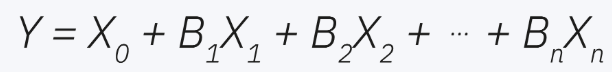

As a start, we'll train a simple linear regression model to predict departure delay. Look at https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html for more information on how linear regression works. As we've seen with various preprocessing functions in the previous session, the pattern for using a model is also very similar across various types of models.

In [ ]:
from sklearn.linear_model import LinearRegression
# First, you define the model.
linear_regressor = LinearRegression()
# Then, you fit the model by giving first the features and second the target values.
linear_regressor.fit(X_train, y_train.to_numpy()) # [:, 1] if you don't have index_col=0 in the third cell reading for y

In [ ]:
# Finally, you make predictions on the test data!
y_pred = linear_regressor.predict(X_test)

We need to evaluate the quality of these predictions. While we will learn more about various metrics tomorrow, for now let's use the coefficient of determination. Very simply speaking, it's a metric that measures how well the predicted value correlates to the actual.

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred) # First comes the true values followed by predicted values.
print(f"R2 score = {round(r2, 3)}")

Given that the best possible score corresponds to 1, this is a great score. To visualize what this actually looks like, let's plot the predictions (y-axis) against the actual values (x-axis) as a scatter plot.

In [ ]:
# Q) Use matplotlib to make the plot described above. Set alpha to 0.5 to make highly populated region more visible.
#  Also, add a y=x line, from 0 to 1000, as a reference line for perfect predictions.
#  Can you also try making the aspect ratio between the two axes the same?
fig, ax = plt.subplots()
ax.scatter(
 # YOUR CODE HERE #
)
ax.plot(
    # YOUR CODE HERE FOR y=x line #
) # HINT : https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html
# YOUR CODE HERE FOR ASPECT RATIO #
ax.set_xlabel("Actual delay (min)")
ax.set_ylabel("Predicted delay (min)")

Although not perfectly on the y=x line, we can see that the predictions show pretty good linear relation with the actual values! Now, let's inspect the linear equation that was trained.

In [ ]:
# But before that, let's collect what each column in the feature matrix (X) corresponded to, for easier inspection.
# Obviously, they need to be collected in the same order as we combined the arrays.
column_names = []
for array in ohe.categories_ :
    column_names.extend(list(array))

column_names.extend(list(std_scaler.feature_names_in_))
column_names.extend(list(minmax_scaler.feature_names_in_))
column_names.extend(["sched_dep_time", "sched_arr_time"])

In [ ]:
linear_regressor.coef_.shape

In [ ]:
linear_regressor.coef_[:, column_names.index("arr_delay")]

In [ ]:
# We have a lot of columns that we fit coefficients on.
# To make things easier, let's take a look at the features with the ten largest absolute values.

# Documentation on argsort: https://numpy.org/doc/stable/reference/generated/numpy.argsort.html
for x in np.argsort(np.abs(linear_regressor.coef_[0, :]))[::-1][:10] :
    print(column_names[int(x)], round(linear_regressor.coef_[0, int(x)], 2))

It looks like features with largest coefficients are dominantly the destination airports. But first of all, what do large coefficients mean? By multiplying the coefficients with the feature value and adding them, we get the final predictions. Because we have scaled all features (but please be cautious that we have not applied the exact scaling schemes across all features), that ROUGHLY means features with large coefficients make larger contributions to the prediction. Does this mean that the destination airports are the most important factor in predicting the departure delay? In some sense, it might be reasonable. Some airports might be prone to delays than others.

While departure delay's dependence on destination airport is a good piece of information, what about other features? Wouldn't the time of the year matter? What about the time that the flight is in the air? Let's see what the model looks like if we limit the dataset to flights with destinations to Honolulu (HNL)! Aloha!

## Modeling for a single destination airport

Since we want to look at data that is relevant to Honolulu only,

1. Let's keep rows that indicate positive in column 59, which specifically corresponds to HNL being the destination
2. Remove columns of all the one-hot encoded columns of different destinations.

In [ ]:
X_train_HNL = np.hstack((
    X_train[np.where(X_train[:, 59]==1)[0], :19], # Just taking the first bits of categorical features
    X_train[np.where(X_train[:, 59]==1)[0], 123:] # and everything after the destination columns
))
X_test_HNL = np.hstack((
    X_test[np.where(X_test[:, 59]==1)[0], :19],
    X_test[np.where(X_test[:, 59]==1)[0], 123:]
))

# Let's try scaling the whole feature data with a standard scaler.
hnl_scaler = StandardScaler()

In [ ]:
# Q) Please standardize the two HNL arrays using the hnl_scaler above.
X_train_HNL_std = # YOUR CODE HERE #
X_test_HNL_std = # YOUR CODE HERE #

In [ ]:
# Defining the y-arrays to correspond to the X
y_train_HNL = y_train.to_numpy()[np.where(X_train[:, 59]==1)[0]] # Note how .to_numpy() is applied before limiting because y_train is a DataFrame
y_test_HNL = y_test.to_numpy()[np.where(X_test[:, 59]==1)[0]]

In [ ]:
# Q) Can you fit a new linear regressor model on the honolulu data that we just prepared above?
hnl_regressor = # YOUR CODE HERE #
# YOUR CODE HERE TO FIT THE REGRESSOR #
y_predicted_HNL = # YOUR CODE HERE TO MAKE PREDICTION #
print(round(r2_score(y_test_HNL, y_predicted_HNL), 3))

It turns out that even for an individual airport, we get good scores!

Let's take a look at the coefficients.

In [ ]:
for i, coef in enumerate(hnl_regressor.coef_[0]):
    if i < 19 :
        print(column_names[i], round(coef, 2))
    else :
        print(column_names[i+104], round(coef, 2)) # 104 because +123 - 19 (19 taken care of in the if clause)

Here, we see that arr_delay column has the largest coefficient. How do you think arrival delay and departure delay would relate to each other?

## Linear regression with only the arrival delay

In [ ]:
# Q) Can you train a linear regressor that predicts the departure delay JUST with the arrival delay?
# The column index for arrival delay is 125 within X_train and X_test.
linear_regressor2 = # YOUR CODE HERE #
# YOUR CODE TO FIT THE REGRESSOR HERE #
predicted_departure_delay2 = # YOUR CODE FOR PREDICTIONS HERE #
print(round(r2_score(y_test, predicted_departure_delay2), 3))

How does the score compare to what we achieved above?

Lastly, let's take a look at what happens if we don't have the arrival delay value.

## Linear regression without the arrival delay

In [ ]:
linear_regressor3 = LinearRegression()
linear_regressor3.fit(
    np.hstack((X_train[:, :125], X_train[:, 126:])),
    y_train
)
print(
    round(r2_score(
        y_test,
        linear_regressor3.predict(
            np.hstack((X_test[:, :125], X_test[:, 126:]))
        )
    ), 3)
)

Given that r2 score of 0 corresponds to no correlation, predictivity from all other features is almost non-existant. This is indicative of the fact that arrival delay values were doing most of the heavy lifting in our original modeling exercise. Such an example here, where you accidentally leave features that are highly correlated with the target values and resulting in a highly predictive model, is an example of **DATA LEAKAGE**. Again, as we mentioned above, information of test instances slipping into the training set is another common cause. It has recently been shown that data leakage is a common problem in ML-based science leading to being overly confident on ML's capabilities in the sciences. An in-depth study on data leakage can be found in this paper: https://arxiv.org/pdf/2207.07048

*It's usually a good idea to doubt surprisingly good scores obtained in the first try.*